# Forecasting time series with missing values

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100;"></i>
    <b style="color: #ff9100;">⚠️ New in skforecast 0.22.0</b>
</p>

Since version 0.22.0, skforecast includes the <code>dropna_from_series</code> parameter in all main forecasters. When set to <code>True</code>, rows with NaN values are automatically dropped from the training matrices before fitting, allowing you to train directly on series with missing values, so no imputation is needed.

For a complete guide on all available strategies, see: <a href="../user_guides/handling-missing-values.ipynb">Handling missing values in time series</a>.

The imputation + weighted forecasting approach described in this document remains a valid and complementary strategy, especially when you want to use **all** observations rather than discarding them.

</div>

In many real use cases of forecasting, although historical data are available, it is common for the time series to be incomplete. The presence of missing values in the data is a major problem since most forecasting algorithms require the time series to be complete in order to train a model.

A commonly employed strategy to overcome this problem is to impute missing values before training the model, for example, using a moving average. However, the quality of the imputations may not be good, impairing the training of the model. One way to improve the imputation strategy is to combine it with [weighted time series forecasting](../user_guides/weighted-time-series-forecasting.html). The latter consists of reducing the weight of the imputed observations and thus their influence during model training.

 This document shows two examples of how **skforecast** makes it easy to apply this strategy.

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from skforecast.datasets import fetch_dataset
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

In this document, a forecaster of type <code>ForecasterRecursive</code> is used. The same strategy can be applied with any forecaster from skforecast.

</div>

In [2]:
# Data download
# ==============================================================================
data = fetch_dataset("bicimad")
data.head(3)

╭──────────────────────────────────── bicimad ─────────────────────────────────────╮
│ Description:                                                                     │
│ This dataset contains the daily users of the bicycle rental service (BiciMad) in │
│ the city of Madrid (Spain) from 2014-06-23 to 2022-09-30.                        │
│                                                                                  │
│ Source:                                                                          │
│ The original data was obtained from: Portal de datos abiertos del Ayuntamiento   │
│ de Madrid https://datos.madrid.es/portal/site/egob                               │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/bicimad_users.csv                                             │
│                                                                                  │
│ Shape: 3022 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

,users
date,
2014-06-23,99
2014-06-24,72
2014-06-25,119


In [3]:
# Generating gaps with missing values
# ==============================================================================
gaps = [
    ['2020-09-01', '2020-10-10'],
    ['2020-11-08', '2020-12-15'],
]

for gap in gaps:
    data.loc[gap[0]:gap[1]] = np.nan

In [4]:
# Split data into train-test
# ==============================================================================
data = data.loc['2020-06-01': '2021-06-01']
end_train = '2021-03-01'
data_train = data.loc[: end_train, :]
data_test  = data.loc[end_train:, :]

print(f"Dates train : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Dates test  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Dates train : 2020-06-01 00:00:00 --- 2021-03-01 00:00:00  (n=274)
Dates test  : 2021-03-01 00:00:00 --- 2021-06-01 00:00:00  (n=93)


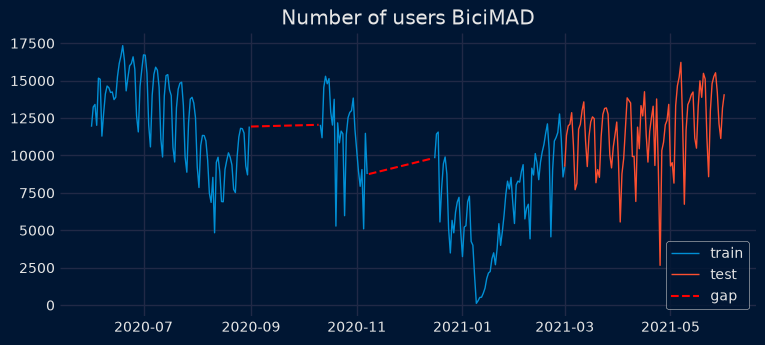

In [5]:
# Time series plot
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(data_train.index, data_train.users, label='train', linewidth=1)
ax.plot(data_test.index, data_test.users, label='test', linewidth=1)

for gap in gaps:
    i_start = data.index.get_loc(pd.to_datetime(gap[0]))
    i_end = data.index.get_loc(pd.to_datetime(gap[1]))
    ax.plot(
        [data.index[i_start], data.index[i_end]],
        [data['users'].iloc[i_start - 1], data['users'].iloc[i_end + 1]],
        color = 'red',
        linestyle = '--',
        label = 'gap'
    )

ax.set_title('Number of users BiciMAD')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right');

## Impute missing values


In [6]:
# Value imputation using linear interpolation
# ======================================================================================
data['users_imputed'] = data['users'].interpolate(method='linear')
data_train = data.loc[: end_train, :]
data_test  = data.loc[end_train:, :]

## Give weight of zero to imputed values

To minimize the influence on the model of imputed values, a custom function is defined to create weights following the rules:

+ Weight of 0 if the index date has been imputed or is within 14 days ahead of an imputed day.

+ Weight of 1 otherwise.

If an observation has a weight of 0, it has no influence at all during model training.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

Imputed values should neither participate in the training process as a target nor as a predictor (lag). Therefore, values within a window size as large as the lags used should also be excluded.

</div>

In [7]:
# Custom function to create weights
# ==============================================================================
def custom_weights(index):
    """
    Return 0 if index is in any gap.
    """
    gaps = [
        ['2020-09-01', '2020-10-10'],
        ['2020-11-08', '2020-12-15'],
    ]

    # Gaps are shifted forward by the window size so imputed values are not used as lags
    missing_dates = [
        pd.date_range(start=gap[0], end=gap[1], freq='D').shift(14, freq='D')
        for gap in gaps
    ]
    missing_dates = missing_dates[0].append(missing_dates[1:])
    weights = np.where(index.isin(missing_dates), 0, 1)

    return weights

`ForecasterRecursive` is trained including the `custom_weights` function.

In [8]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator   = LGBMRegressor(random_state=123, verbose=-1),
                 lags        = 14,
                 weight_func = custom_weights
             )

# Backtesting: predict the next 7 days at a time.
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 7,
         initial_train_size = len(data.loc[:end_train]),
         refit              = True,
         fixed_train_size   = False,
     )

metric, predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data.users_imputed,
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False,
                          show_progress = True
                      )

metric

  0%|          | 0/14 [00:00<?, ?it/s]

,mean_absolute_error
0,1904.830714


In [9]:
# Backtest predictions
# ==============================================================================
predictions.head(4)

,fold,pred
2021-03-02,0,10524.159747
2021-03-03,0,10087.283682
2021-03-04,0,8882.926166
2021-03-05,0,9474.810215
